/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/predicates.py:806: Runtim

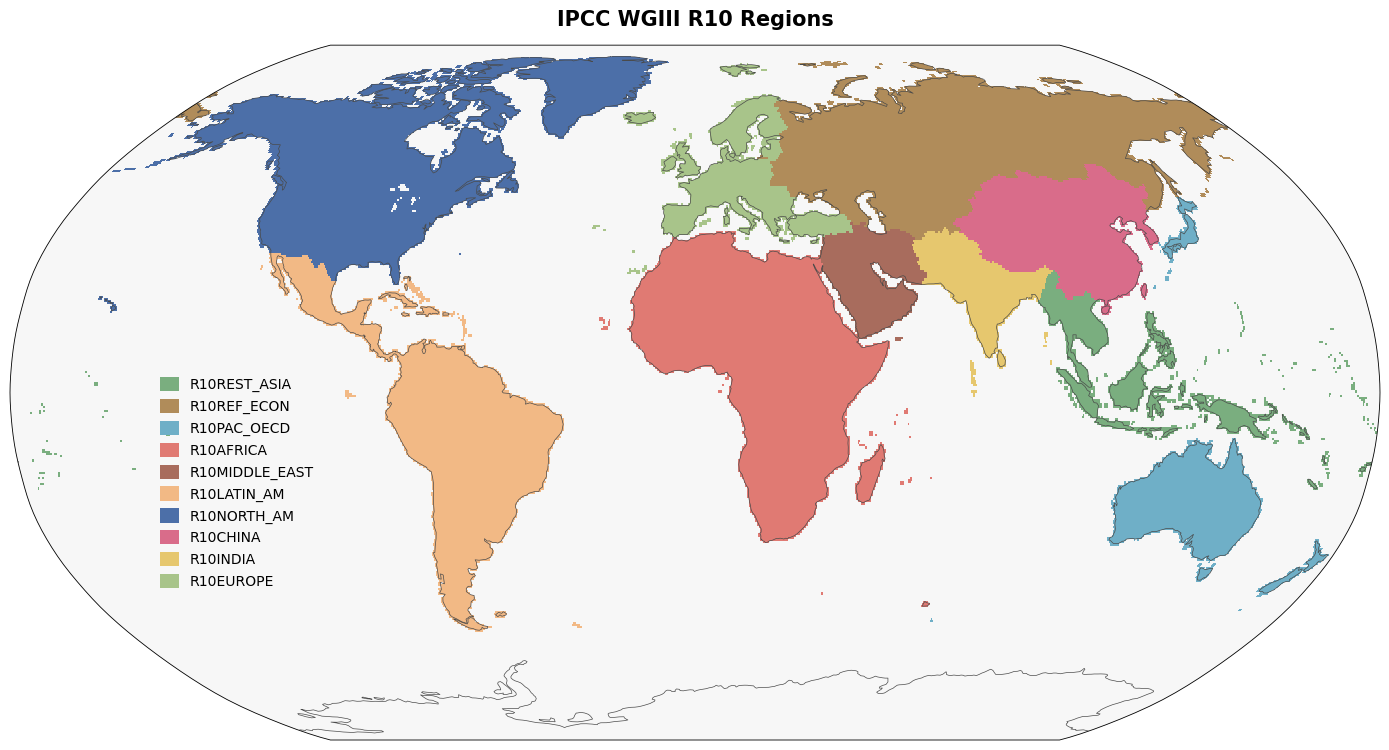

Saved:
- r10_regions_map_distinct_colors.png
- r10_regions_map_distinct_colors.pdf


In [1]:
#This code is used to plot R10 regions used in this study from IPCC WG3 classification r10 regions mask (Smith et al., 2023)
# pip install xarray netCDF4 matplotlib cartopy if needed

from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --------------------------------------------------
# Input file
# --------------------------------------------------
nc_path = Path("r10masks_fractional.nc")

# --------------------------------------------------
# Region names matched to the NetCDF file (0-9 only)
# --------------------------------------------------
region_names = [
    "R10REST_ASIA",   # 0 = South-East Asia and developing Pacific
    "R10REF_ECON",    # 1 = Eurasia
    "R10PAC_OECD",    # 2 = Asia-Pacific
    "R10AFRICA",      # 3 = Africa
    "R10MIDDLE_EAST", # 4 = Middle East
    "R10LATIN_AM",    # 5 = Latin America and Caribbean
    "R10NORTH_AM",    # 6 = North America
    "R10CHINA",       # 7 = Eastern Asia
    "R10INDIA",       # 8 = Southern Asia
    "R10EUROPE",      # 9 = Europe
]

# --------------------------------------------------
# Distinct muted palette
# Chosen to avoid near-duplicates
# --------------------------------------------------
region_colors = [
    "#7AAE7F",  # R10REST_ASIA   muted green
    "#B08C5A",  # R10REF_ECON    brown/khaki
    "#6FAFC7",  # R10PAC_OECD    light blue-teal
    "#E07A73",  # R10AFRICA      muted coral
    "#A86C5D",  # R10MIDDLE_EAST earthy brown-red
    "#F2B985",  # R10LATIN_AM    warm peach
    "#4C6FA8",  # R10NORTH_AM    deeper blue
    "#D96C8A",  # R10CHINA       rose
    "#E6C76E",  # R10INDIA       muted mustard
    "#A8C48A",  # R10EUROPE      light olive
]

# --------------------------------------------------
# Load dataset
# --------------------------------------------------
ds = xr.open_dataset(nc_path)

# Main variable from the verified file metadata
var_name = "r10_code" if "r10_code" in ds.data_vars else list(ds.data_vars)[0]
da = ds[var_name]

reg_dim, lat_dim, lon_dim = da.dims[:3]

# Keep only 0-9, excluding 10 = World
frac = da.isel({reg_dim: slice(0, 10)})

# Dominant region assignment for each grid cell
dominant_region = frac.argmax(dim=reg_dim)

# Mask non-land/ocean cells
land_fraction = frac.sum(dim=reg_dim)
dominant_region = dominant_region.where(land_fraction > 0)

lat = ds[lat_dim].values
lon = ds[lon_dim].values

# Convert longitudes to -180..180 if needed
if lon.max() > 180:
    lon_wrapped = ((lon + 180) % 360) - 180
    order = np.argsort(lon_wrapped)
    lon = lon_wrapped[order]
    dominant_region = dominant_region.isel({lon_dim: order})

# Ensure latitudes increase from south to north
if lat[0] > lat[-1]:
    lat = lat[::-1]
    dominant_region = dominant_region.isel({lat_dim: slice(None, None, -1)})

# --------------------------------------------------
# Plot style
# --------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.linewidth": 0.6,
})

cmap = ListedColormap(region_colors)
cmap.set_bad("#F7F7F7")
norm = BoundaryNorm(np.arange(-0.5, 10.5, 1), cmap.N)

fig = plt.figure(figsize=(14, 8), facecolor="white")
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.set_facecolor("#F7F7F7")

ax.pcolormesh(
    lon,
    lat,
    dominant_region,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading="auto",
    rasterized=True,
    zorder=2
)

ax.add_feature(cfeature.OCEAN, facecolor="#F7F7F7", zorder=0)
ax.coastlines(linewidth=0.5, color="#4A4A4A", zorder=3)



ax.set_title("IPCC WGIII R10 Regions", fontsize=15, weight="bold", pad=14)

legend_handles = [
    Patch(facecolor=region_colors[i], edgecolor="none", label=region_names[i])
    for i in range(10)
]

ax.legend(
    handles=legend_handles,
    loc="lower left",
    bbox_to_anchor=(0.1, 0.2),
    ncol=1,
    frameon=False,
    fontsize=10,
    handlelength=1.4,
    handleheight=1.2,
    columnspacing=1.6
)

plt.tight_layout()

# --------------------------------------------------
# Save output
# --------------------------------------------------
out_png = nc_path.with_name("r10_regions_map_distinct_colors.png")
out_pdf = nc_path.with_name("r10_regions_map_distinct_colors.pdf")

plt.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(out_pdf, dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved:\n- {out_png}\n- {out_pdf}")